In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report


In [3]:
df=pd.read_excel('data1.xlsx')
df.head()

,Feature_1,Feature_2,Target_Class
0,0.893586,-0.351167,0
1,0.621767,0.808279,0
2,-0.232287,0.836077,0
3,-0.428056,-0.115387,1
4,-0.155135,0.531316,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Feature_1     200 non-null    float64
 1   Feature_2     200 non-null    float64
 2   Target_Class  200 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 4.8 KB


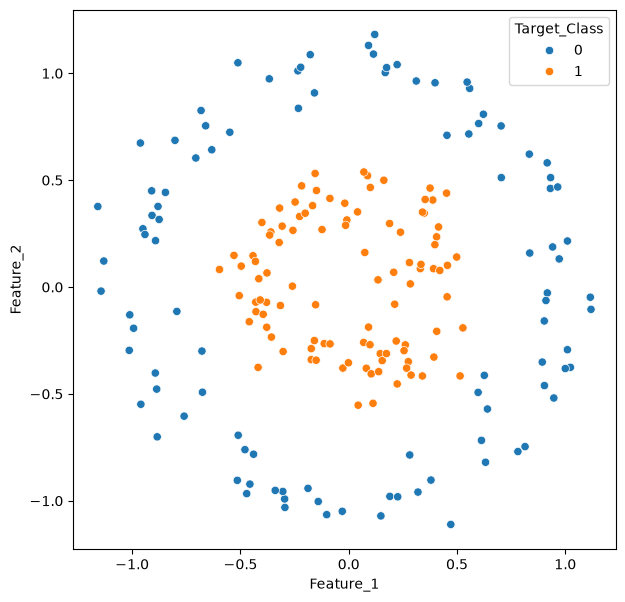

In [8]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Target_Class')
plt.show()

In [9]:
x=df.drop('Target_Class',axis=1)
y=df['Target_Class']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)
print(f"Training data shape: {xtrain.shape}, Testing data shape: {xtest.shape}")

Training data shape: (160, 2), Testing data shape: (40, 2)


In [14]:
#LINEAR SVM
mod=SVC(kernel='linear',C=1.0)
mod.fit(xtrain,ytrain)
print(f"Accuracy = {accuracy_score(ytest, mod.predict(xtest))*100}% ")
print(classification_report(ytest, mod.predict(xtest)))

Accuracy = 42.5% 
              precision    recall  f1-score   support

           0       0.42      1.00      0.60        17
           1       0.00      0.00      0.00        23

    accuracy                           0.42        40
   macro avg       0.21      0.50      0.30        40
weighted avg       0.18      0.42      0.25        40



/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [17]:
#polinomial kernel 
from sklearn.model_selection import GridSearchCV


In [25]:
mod=SVC(kernel='poly')
deg={
    'degree':[1,2,3,4],
}
tester=GridSearchCV(estimator=mod,param_grid=deg,cv=5)
tester.fit(xtrain,ytrain)
print(f"Best degree = {tester.best_params_}")
mod=tester.best_estimator_

Best degree = {'degree': 2}


In [26]:
print(f"Accuracy = {accuracy_score(ytest, mod.predict(xtest))*100}% ")
print(classification_report(ytest, mod.predict(xtest)))

Accuracy = 100.0% 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        23

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [28]:
mod=SVC(kernel='rbf',C=1)
mod.fit(xtrain,ytrain)
print(f"Accuracy = {accuracy_score(ytest, mod.predict(xtest))*100}% ")
print(classification_report(ytest, mod.predict(xtest)))

Accuracy = 100.0% 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        23

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



<Axes: xlabel='Feature_1', ylabel='Feature_2'>

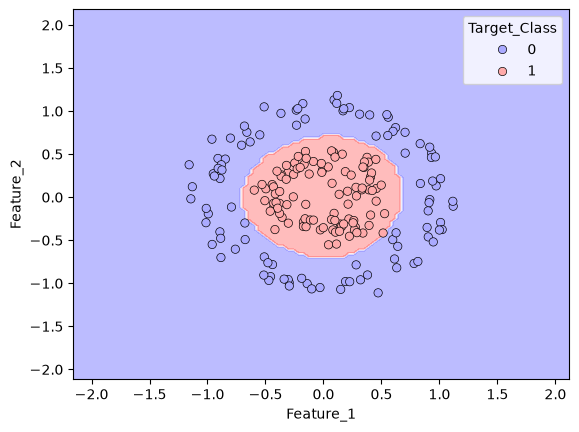

In [30]:
from sklearn.inspection import DecisionBoundaryDisplay

DecisionBoundaryDisplay.from_estimator(
    mod, x, response_method="predict", cmap="bwr", alpha=0.3
)

sns.scatterplot(data=df, x='Feature_1', y='Feature_2', hue='Target_Class', palette='bwr', edgecolor='k')
